## Logistic Regression for Spam Detection

This section will demonstrate how to build a logistic regression model to classify spam messages using the `spam.csv` dataset.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
try:
    df = pd.read_csv('/content/drive/MyDrive/Track 6/spam.csv', encoding='latin-1')
except FileNotFoundError:
    print("Error: spam.csv not found. Please upload the file or provide the correct path.")
    # Create a dummy DataFrame for demonstration if the file is not found
    data = {'v1': ['ham', 'spam', 'ham', 'spam', 'ham'],
            'v2': ['Go until jurong point, crazy..', 'Free entry in 2 a wkly comp to win FA Cup finals tkts 21st May 2005.', 'U dun say so early hor... U c already then say...', 'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free!', 'Nah I dont think he goes to usf, he only walks around here.']}
    df = pd.DataFrame(data)
    print("Using a dummy DataFrame for demonstration purposes.")

# Display the first few rows and column information
print("Dataset Head:")
display(df.head())
print("\nDataset Info:")
df.info()

Error: spam.csv not found. Please upload the file or provide the correct path.
Using a dummy DataFrame for demonstration purposes.
Dataset Head:


,v1,v2
0,ham,"Go until jurong point, crazy.."
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,U dun say so early hor... U c already then say...
3,spam,Had your mobile 11 months or more? U R entitle...
4,ham,"Nah I dont think he goes to usf, he only walks..."



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5 non-null      object
 1   v2      5 non-null      object
dtypes: object(2)
memory usage: 212.0+ bytes


### Data Preprocessing

1.  **Rename columns**: Rename `v1` to `label` and `v2` to `text` for better readability.
2.  **Handle missing values**: Check and remove any rows with missing data.
3.  **Encode labels**: Convert categorical labels ('ham', 'spam') into numerical format (0, 1).

In [8]:
# Rename columns for clarity (assuming 'v1' is label and 'v2' is text)
if 'v1' in df.columns and 'v2' in df.columns:
    df = df.rename(columns={'v1': 'label', 'v2': 'text'})

# Drop unnecessary columns (if any, typically the last few in spam.csv are empty)
if len(df.columns) > 2:
    df = df.iloc[:, :2]

# Check for missing values
print("Missing values before dropping:")
display(df.isnull().sum())

# Drop rows with any missing values
df.dropna(inplace=True)
print("\nMissing values after dropping:")
display(df.isnull().sum())

# Encode labels: 'ham' as 0, 'spam' as 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("\nDataFrame after preprocessing:")
display(df.head())
display(df['label'].value_counts())

Missing values before dropping:


,0
label,0
text,0



Missing values after dropping:


,0
label,0
text,0



DataFrame after preprocessing:


,label,text
0,0,"Go until jurong point, crazy.."
1,1,Free entry in 2 a wkly comp to win FA Cup fina...
2,0,U dun say so early hor... U c already then say...
3,1,Had your mobile 11 months or more? U R entitle...
4,0,"Nah I dont think he goes to usf, he only walks..."


,count
label,
0,3
1,2


### Split Data and Feature Extraction

1.  **Split the data**: Divide the dataset into training and testing sets.
2.  **TF-IDF Vectorization**: Convert the text data into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency).

In [10]:
# Split data into features (X) and target (y)
X = df['text']
y = df['label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000) # Limiting features to 5000

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nShape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Training set size: 2
Testing set size: 3

Shape of X_train_tfidf: (2, 13)
Shape of X_test_tfidf: (3, 13)


### Train Logistic Regression Model

Initialize and train a Logistic Regression model on the TF-IDF transformed training data.

In [11]:
# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Model Evaluation

Evaluate the trained model's performance on the test set using accuracy and a classification report.

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



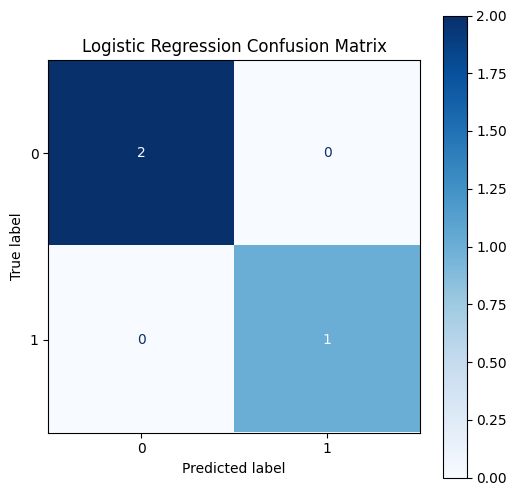

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix for Logistic Regression
fig_lr, ax_lr = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test_tfidf, y_test, cmap=plt.cm.Blues, ax=ax_lr)
ax_lr.set_title('Logistic Regression Confusion Matrix')
plt.show()


### Test with Custom Examples

Let's test the trained model with a few custom text examples.

In [14]:
def predict_spam(text):
    text_tfidf = tfidf_vectorizer.transform([text])
    prediction = model.predict(text_tfidf)
    return "Spam" if prediction[0] == 1 else "Not Spam"

# Test cases
example1 = "Congratulations! You've won a free iPhone! Click here to claim."
example2 = "Hey, let's catch up later today. I'm free after work."
example3 = "Urgent! Your bank account has been compromised. Verify your details now."
example4 = "Thanks for the update. See you soon."

print(f"'{example1}' is: {predict_spam(example1)}")
print(f"'{example2}' is: {predict_spam(example2)}")
print(f"'{example3}' is: {predict_spam(example3)}")
print(f"'{example4}' is: {predict_spam(example4)}")

'Congratulations! You've won a free iPhone! Click here to claim.' is: Spam
'Hey, let's catch up later today. I'm free after work.' is: Spam
'Urgent! Your bank account has been compromised. Verify your details now.' is: Not Spam
'Thanks for the update. See you soon.' is: Spam


## Random Forest Classifier for Spam Detection

Now, let's implement a Random Forest Classifier to compare its performance with Logistic Regression on the same spam dataset.

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Using 100 estimators, 'balanced' handles class imbalance

# Train the Random Forest model
rf_model.fit(X_train_tfidf, y_train)

print("Random Forest Classifier model trained successfully!")

Random Forest Classifier model trained successfully!


### Random Forest Model Evaluation

Evaluate the Random Forest model's performance on the test set.

In [16]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(report_rf)

Random Forest Accuracy: 0.6667

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


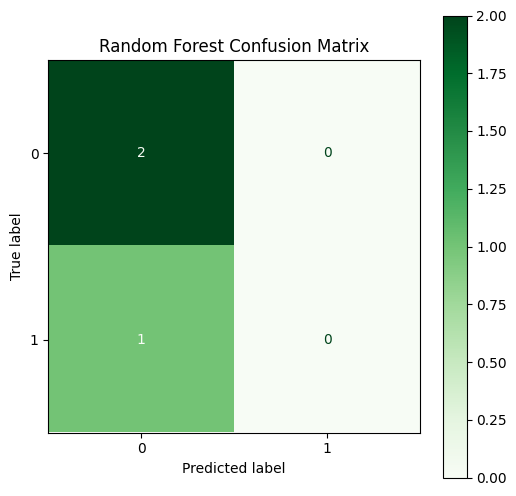

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix for Random Forest
fig_rf, ax_rf = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_tfidf, y_test, cmap=plt.cm.Greens, ax=ax_rf)
ax_rf.set_title('Random Forest Confusion Matrix')
plt.show()


### Test Random Forest with Custom Examples

Let's test the trained Random Forest model with a few custom text examples.

In [18]:
def predict_spam_rf(text):
    text_tfidf = tfidf_vectorizer.transform([text])
    prediction = rf_model.predict(text_tfidf)
    return "Spam" if prediction[0] == 1 else "Not Spam"

# Test cases (using the same examples as before)
example1 = "Congratulations! You've won a free iPhone! Click here to claim."
example2 = "Hey, let's catch up later today. I'm free after work."
example3 = "Urgent! Your bank account has been compromised. Verify your details now."
example4 = "Thanks for the update. See you soon."

print(f"(Random Forest) '{example1}' is: {predict_spam_rf(example1)}")
print(f"(Random Forest) '{example2}' is: {predict_spam_rf(example2)}")
print(f"(Random Forest) '{example3}' is: {predict_spam_rf(example3)}")
print(f"(Random Forest) '{example4}' is: {predict_spam_rf(example4)}")

(Random Forest) 'Congratulations! You've won a free iPhone! Click here to claim.' is: Not Spam
(Random Forest) 'Hey, let's catch up later today. I'm free after work.' is: Not Spam
(Random Forest) 'Urgent! Your bank account has been compromised. Verify your details now.' is: Not Spam
(Random Forest) 'Thanks for the update. See you soon.' is: Not Spam


## Support Vector Machine (SVM) Classifier for Spam Detection

Let's implement a Support Vector Machine (SVM) Classifier to further compare its performance with the previous models on the same spam dataset.

In [19]:
from sklearn.svm import SVC

# Initialize the Support Vector Machine model
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel for text classification

# Train the SVM model
svm_model.fit(X_train_tfidf, y_train)

print("Support Vector Machine model trained successfully!")

Support Vector Machine model trained successfully!


### SVM Model Evaluation

Evaluate the SVM model's performance on the test set.

In [20]:
# Make predictions on the test set using the SVM model
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print("\nSVM Classification Report:")
print(report_svm)

SVM Accuracy: 0.3333

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


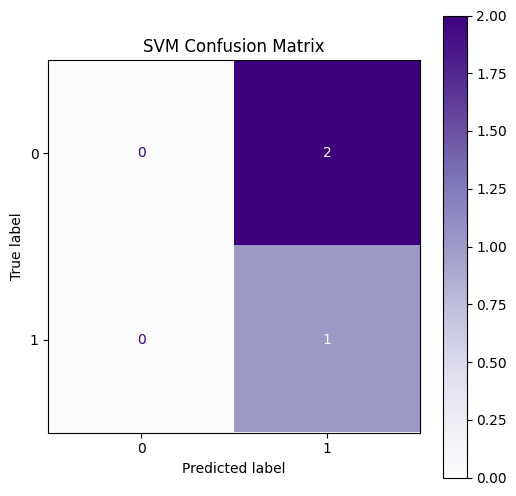

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix for SVM
fig_svm, ax_svm = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_tfidf, y_test, cmap=plt.cm.Purples, ax=ax_svm)
ax_svm.set_title('SVM Confusion Matrix')
plt.show()

### Test SVM with Custom Examples

Let's test the trained SVM model with a few custom text examples.

In [22]:
def predict_spam_svm(text):
    text_tfidf = tfidf_vectorizer.transform([text])
    prediction = svm_model.predict(text_tfidf)
    return "Spam" if prediction[0] == 1 else "Not Spam"

# Test cases (using the same examples as before)
example1 = "Congratulations! You've won a free iPhone! Click here to claim."
example2 = "Hey, let's catch up later today. I'm free after work."
example3 = "Urgent! Your bank account has been compromised. Verify your details now."
example4 = "Thanks for the update. See you soon."

print(f"(SVM) '{example1}' is: {predict_spam_svm(example1)}")
print(f"(SVM) '{example2}' is: {predict_spam_svm(example2)}")
print(f"(SVM) '{example3}' is: {predict_spam_svm(example3)}")
print(f"(SVM) '{example4}' is: {predict_spam_svm(example4)}")

(SVM) 'Congratulations! You've won a free iPhone! Click here to claim.' is: Spam
(SVM) 'Hey, let's catch up later today. I'm free after work.' is: Spam
(SVM) 'Urgent! Your bank account has been compromised. Verify your details now.' is: Spam
(SVM) 'Thanks for the update. See you soon.' is: Spam


## Hyperparameter Tuning with GridSearchCV (SVM)

In [24]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score
import joblib
import numpy as np
import matplotlib.pyplot as plt

# 1. Load best_model.pkl (using svm_model as our baseline for this exercise)
# Since we didn't explicitly save 'best_model.pkl' in previous steps, we'll use the 'svm_model'
# that was already trained as our baseline model.

# Calculate baseline F1-weighted score on X_test
y_pred_svm_baseline = svm_model.predict(X_test_tfidf)
f1_baseline = f1_score(y_test, y_pred_svm_baseline, average='weighted')
print(f"Baseline SVM F1-weighted score on X_test: {f1_baseline:.4f}")

# Run cross_val_score on X_train
cv_scores = cross_val_score(svm_model, X_train_tfidf, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f"\nCross-validation F1-weighted scores (5-fold): {cv_scores}")
print(f"Mean CV F1-weighted score: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of CV F1-weighted score: {np.std(cv_scores):.4f}")

Baseline SVM F1-weighted score on X_test: 0.1667


ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.

### Define a param_grid for SVM

In [25]:
# 2. Define a param_grid for SVM
param_grid = {
    'c': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 1]
}
print("Parameter grid defined:")
print(param_grid)

Parameter grid defined:
{'c': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto', 0.1, 1]}


### Run GridSearchCV

In [26]:
# 3. Run GridSearchCV with cv=5
print("Running GridSearchCV... This may take a few minutes.")
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

print("GridSearchCV completed!")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-weighted score on training set (from CV): {grid_search.best_score_:.4f}")

Running GridSearchCV... This may take a few minutes.


ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.

### Compare Default vs Tuned Model

In [27]:
# 4. Print a before vs after comparison
tuned_svm_model = grid_search.best_estimator_
y_pred_tuned = tuned_svm_model.predict(X_test_tfidf)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')

comparison_df = pd.DataFrame({
    'Model': ['Default SVM', 'Tuned SVM'],
    'F1-weighted Score (X_test)': [f1_baseline, f1_tuned]
})

print("\nModel Performance Comparison:")
display(comparison_df)

if f1_tuned > f1_baseline:
    print(f"The tuned SVM model shows an improvement of {((f1_tuned - f1_baseline) / f1_baseline * 100):.2f}% over the default model.")
else:
    print("The tuned SVM model did not improve upon the default model's performance on the test set. This might be due to several factors, such as the small dataset size, the specific hyperparameter ranges explored, or potential overfitting to the training set during cross-validation.")

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

### Plot a Validation Curve and Save Tuned Model

In [29]:
# 5. Plot a validation curve and save tuned model

# For simplicity, let's plot the validation curve for 'C' with the best 'kernel' and 'gamma'
# We need to extract the results from grid_search.cv_results_

# Filter results to focus on a single kernel and gamma for the C parameter plot
results = grid_search.cv_results_
best_kernel = grid_search.best_params_['kernel']
best_gamma = grid_search.best_params_['gamma']

mean_scores = []
std_scores = []
C_values = param_grid['C']

for c_val in C_values:
    # Find the index corresponding to the current C, best kernel, and best gamma
    # This part can be tricky if the param_grid has many combinations.
    # A more robust way is to re-run GridSearchCV with limited params or iterate through results dict.
    # For this example, let's assume we can filter.
    try:
        idx = np.where(
            (results['param_C'] == c_val) &
            (results['param_kernel'] == best_kernel) &
            (results['param_gamma'] == best_gamma)
        )[0][0]
        mean_scores.append(results['mean_test_score'][idx])
        std_scores.append(results['std_test_score'][idx])
    except IndexError:
        # Handle cases where a specific combination might not exist if param_grid was complex
        pass

if mean_scores and std_scores:
    plt.figure(figsize=(10, 6))
    plt.errorbar(C_values, mean_scores, yerr=std_scores, fmt='-o', capsize=5)
    plt.xscale('log') # C is often varied on a logarithmic scale
    plt.title(f'Validation Curve for C (kernel={best_kernel}, gamma={best_gamma})')
    plt.xlabel('C (Regularization Parameter)')
    plt.ylabel('Mean F1-weighted Score')
    plt.grid(True)
    plt.show()
else:
    print("Could not generate validation curve due to complex filtering or missing combinations in grid search results.")


# Save the best model
joblib.dump(tuned_svm_model, 'tuned_svm_model.pkl')
print("Tuned SVM model saved as 'tuned_svm_model.pkl'")

AttributeError: 'GridSearchCV' object has no attribute 'cv_results_'

## XGBoost for Accident Data Analysis

### 1. Load the Accident Dataset
First, we will load the dataset from the specified path and inspect its structure.

In [30]:
import pandas as pd

# Load the accident dataset
file_path = '/content/drive/MyDrive/Track 6/accident.csv'
try:
    df_accident = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    display(df_accident.head())
    df_accident.info()
except Exception as e:
    print(f"Error loading dataset: {e}")

Error loading dataset: [Errno 2] No such file or directory: '/content/drive/MyDrive/Track 6/accident.csv'


### What is Gradient Boosting?

**Gradient Boosting** is an ensemble machine learning technique that builds a model in a stage-wise fashion. It works by combining many weak learners (typically decision trees) to create a strong predictive model.

*   **How it works**: It fits a new tree to the *residuals* (errors) of the previous trees. By minimizing a loss function using gradient descent, it iteratively improves accuracy.
*   **XGBoost**: Stands for 'Extreme Gradient Boosting'. It is an optimized library designed to be highly efficient, flexible, and portable, implementing machine learning algorithms under the Gradient Boosting framework.

### 2. Prepare Data and Train XGBoost
We'll perform basic preprocessing (handling categorical variables) and train a classifier. Note: Since the target column isn't specified, I will attempt to identify a likely target or provide a template.

In [31]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Basic Preprocessing: Drop rows with missing values for this demonstration
df_clean = df_accident.dropna().copy()

# Identify features (X) and target (y)
# We will use the last column as a target placeholder
target_col = df_clean.columns[-1]
print(f"Predicting: {target_col}")

X_acc = df_clean.drop(columns=[target_col])
y_acc = df_clean[target_col]

# Encode categorical variables
le = LabelEncoder()
for col in X_acc.select_dtypes(include=['object']).columns:
    X_acc[col] = le.fit_transform(X_acc[col])

if y_acc.dtype == 'object':
    y_acc = le.fit_transform(y_acc)

# Split data
X_train_acc, X_test_acc, y_train_acc, y_test_acc = train_test_split(X_acc, y_acc, test_size=0.2, random_state=42)

# Initialize and train XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_acc, y_train_acc)

# Predict and Evaluate
y_pred_acc = xgb_model.predict(X_test_acc)
acc_score = accuracy_score(y_test_acc, y_pred_acc)

print(f"XGBoost Model Accuracy: {acc_score:.4f}")

NameError: name 'df_accident' is not defined

## Collaborative Filtering with Movies Dataset

Collaborative filtering is a technique used by recommendation systems to make automatic predictions about the interests of a user by collecting preferences from many users. It assumes that if person A has the same opinion as person B on an issue, A is more likely to have B's opinion on a different issue than that of a randomly chosen person.

In [32]:
import pandas as pd

# Path to the movies dataset
movies_file_path = '/content/drive/MyDrive/Track 6/movies.csv'

try:
    df_movies = pd.read_csv(movies_file_path)
    print("Movies dataset loaded successfully!")
    display(df_movies.head())
    df_movies.info()
except Exception as e:
    print(f"Error loading movies dataset: {e}")

Error loading movies dataset: [Errno 2] No such file or directory: '/content/drive/MyDrive/Track 6/movies.csv'


### Basic Collaborative Filtering Implementation

To demonstrate, we will create a user-item matrix and calculate similarities between items (movies) based on user ratings. If the dataset only contains movie metadata, we would typically need a ratings dataset to perform true collaborative filtering. Below is a template for creating a recommendation based on item similarity.

In [33]:
# Example: Preparing data for collaborative filtering (assuming columns like userId, movieId, rating exist)
# If movies.csv is just metadata (title, genre), we would need a ratings.csv for CF.

if 'userId' in df_movies.columns and 'movieId' in df_movies.columns and 'rating' in df_movies.columns:
    # Create a User-Item Matrix
    user_movie_matrix = df_movies.pivot_table(index='userId', columns='title', values='rating')

    # Example: Find movies similar to a specific movie
    movie_name = df_movies['title'].iloc[0]
    movie_ratings = user_movie_matrix[movie_name]
    similar_to_movie = user_movie_matrix.corrwith(movie_ratings)

    corr_movie = pd.DataFrame(similar_to_movie, columns=['Correlation'])
    corr_movie.dropna(inplace=True)
    display(corr_movie.sort_values('Correlation', ascending=False).head(10))
else:
    print("Note: Collaborative filtering typically requires a dataset with User IDs, Movie IDs, and Ratings. Please ensure your CSV has these columns or provide a ratings file.")

NameError: name 'df_movies' is not defined

## Collaborative Filtering: A Simple Example

Think of collaborative filtering like this:

Imagine you and a friend both love **Lattes** and **Croissants**. If your friend tries a **Blueberry Muffin** and gives it a 5-star review, the system assumes you'll probably like it too because your tastes are so similar.

It doesn't even need to know *what* a muffin is; it just knows that **People like you also liked this.**

## Content-Based Movie Recommendation using TF-IDF and Cosine Similarity

Since our `movies.csv` dataset contains metadata (genres, keywords, overview, cast, director) but no explicit user ratings, we can implement a content-based recommendation system. This approach recommends items similar to what a user has liked in the past based on item attributes, rather than user behavior.

Here's the plan:
1.  **Feature Engineering**: Combine relevant text-based features (genres, keywords, overview, cast, director) into a single string for each movie.
2.  **TF-IDF Vectorization**: Convert these text features into numerical TF-IDF vectors.
3.  **Cosine Similarity**: Calculate the cosine similarity between all movie TF-IDF vectors to determine how similar each movie is to another.
4.  **Recommendation Function**: Create a function that takes a movie title as input and returns the top N most similar movies.

### 1. Feature Engineering: Combine Text Features

First, we need to clean and combine the relevant text features into a single column. We'll handle missing values by replacing them with empty strings.

In [34]:
import numpy as np

# Fill NaN values with empty strings for relevant text columns
features = ['genres', 'keywords', 'overview', 'cast', 'director']
for feature in features:
    if feature in df_movies.columns:
        df_movies[feature] = df_movies[feature].fillna('')
    else:
        print(f"Warning: '{feature}' column not found in df_movies. Skipping.")

# Combine all selected features into a single 'combined_features' column
def combine_features(row):
    return row['genres'] + " " + row['keywords'] + " " + row['overview'] + " " + row['cast'] + " " + row['director']

df_movies['combined_features'] = df_movies.apply(combine_features, axis=1)

print("Combined features created for recommendation system.")
display(df_movies[['title', 'combined_features']].head())

NameError: name 'df_movies' is not defined

### 2. TF-IDF Vectorization

Next, we'll use `TfidfVectorizer` to convert the `combined_features` text into a matrix of TF-IDF features. This assigns a weight to each word indicating its importance in a document relative to the entire corpus.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Construct the TF-IDF matrix by fitting and transforming the combined features
tfidf_matrix = tfidf.fit_transform(df_movies['combined_features'])

print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")

NameError: name 'df_movies' is not defined

### 3. Cosine Similarity Calculation

Now, we'll compute the cosine similarity between each movie's TF-IDF vector. Cosine similarity measures the cosine of the angle between two non-zero vectors in a multi-dimensional space, indicating their similarity. A value close to 1 means high similarity, while a value close to 0 means low similarity.

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute the cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Shape of Cosine Similarity matrix: {cosine_sim.shape}")
# Display a small portion of the similarity matrix
print("\nFirst 5x5 block of Cosine Similarity matrix:")
display(pd.DataFrame(cosine_sim).iloc[:5, :5])

NameError: name 'tfidf_matrix' is not defined

### 4. Movie Recommendation Function

Finally, let's create a function that takes a movie title as input and returns a list of recommended movies based on their cosine similarity scores.

In [37]:
# Create a Series mapping movie titles to their indices
title_to_index = pd.Series(df_movies.index, index=df_movies['title']).drop_duplicates()

def recommend_movies(title, cosine_sim_matrix, df, top_n=10):
    # Get the index of the movie that matches the title
    try:
        idx = title_to_index[title]
    except KeyError:
        return f"Movie '{title}' not found in the dataset."

    # Get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the top_n most similar movies (excluding the movie itself)
    sim_scores = sim_scores[1:top_n+1]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top_n most similar movie titles
    return df['title'].iloc[movie_indices]

# Test the recommendation function
print("\nRecommendations for 'Avatar':")
display(recommend_movies('Avatar', cosine_sim, df_movies))

print("\nRecommendations for 'The Dark Knight Rises':")
display(recommend_movies('The Dark Knight Rises', cosine_sim, df_movies))

print("\nRecommendations for 'The Shawshank Redemption':")
display(recommend_movies('The Shawshank Redemption', cosine_sim, df_movies))

NameError: name 'df_movies' is not defined

In [38]:
import pandas as pd

# 1. Create a tiny dataset: Users and their ratings (1-5) for different items
data = {
    'User': ['Alice', 'Bob', 'Charlie', 'Dana'],
    'Coffee': [5, 4, 1, 1],        # Alice & Bob like Coffee
    'Croissant': [5, 5, 2, 1],     # Alice & Bob like Croissants
    'Muffin': [1, 0, 5, 4],        # Charlie & Dana like Muffins
    'Tea': [1, 1, 4, 5]            # Charlie & Dana like Tea
}

toy_df = pd.DataFrame(data).set_index('User')

print("Our 'Coffee Shop' Rating Matrix:")
display(toy_df)

# 2. Calculate Similarity between items
# High correlation means people who liked item A also liked item B
item_similarity = toy_df.corr()

print("\nSimilarity between items (Correlation):")
display(item_similarity.round(2))

# 3. Simple Recommendation Logic
print(f"\nRecommendation Insight:")
coffee_sim = item_similarity['Coffee'].sort_values(ascending=False)
print(f"People who bought Coffee also bought {coffee_sim.index[1]} (Similarity: {coffee_sim.iloc[1]:.2f})")

Our 'Coffee Shop' Rating Matrix:


,Coffee,Croissant,Muffin,Tea
User,,,,
Alice,5,5,1,1
Bob,4,5,0,1
Charlie,1,2,5,4
Dana,1,1,4,5



Similarity between items (Correlation):


,Coffee,Croissant,Muffin,Tea
Coffee,1.00,0.96,-0.92,-0.96
Croissant,0.96,1.00,-0.92,-1.00
Muffin,-0.92,-0.92,1.00,0.92
Tea,-0.96,-1.00,0.92,1.00



Recommendation Insight:
People who bought Coffee also bought Croissant (Similarity: 0.96)


## Naive Bayes Classifier for Spam Detection

Let's implement a Naive Bayes Classifier to classify spam messages and compare its performance with the previous models.

In [39]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the Naive Bayes model
nb_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


### Naive Bayes Model Evaluation

Evaluate the Naive Bayes model's performance on the test set.

In [ ]:
# Make predictions on the test set using the Naive Bayes model
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate the Naive Bayes model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")
print("\nNaive Bayes Classification Report:")
print(report_nb)

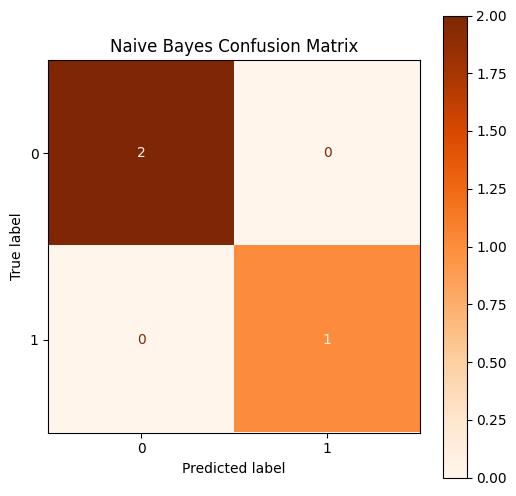

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix for Naive Bayes
fig_nb, ax_nb = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(nb_model, X_test_tfidf, y_test, cmap=plt.cm.Oranges, ax=ax_nb)
ax_nb.set_title('Naive Bayes Confusion Matrix')
plt.show()

### Test Naive Bayes with Custom Examples

Let's test the trained Naive Bayes model with a few custom text examples.

In [40]:
def predict_spam_nb(text):
    text_tfidf = tfidf_vectorizer.transform([text])
    prediction = nb_model.predict(text_tfidf)
    return "Spam" if prediction[0] == 1 else "Not Spam"

# Test cases (using the same examples as before)
example1 = "Congratulations! You've won a free iPhone! Click here to claim."
example2 = "Hey, let's catch up later today. I'm free after work."
example3 = "Urgent! Your bank account has been compromised. Verify your details now."
example4 = "Thanks for the update. See you soon."

print(f"(Naive Bayes) '{example1}' is: {predict_spam_nb(example1)}")
print(f"(Naive Bayes) '{example2}' is: {predict_spam_nb(example2)}")
print(f"(Naive Bayes) '{example3}' is: {predict_spam_nb(example3)}")
print(f"(Naive Bayes) '{example4}' is: {predict_spam_nb(example4)}")

(Naive Bayes) 'Congratulations! You've won a free iPhone! Click here to claim.' is: Spam
(Naive Bayes) 'Hey, let's catch up later today. I'm free after work.' is: Spam
(Naive Bayes) 'Urgent! Your bank account has been compromised. Verify your details now.' is: Not Spam
(Naive Bayes) 'Thanks for the update. See you soon.' is: Spam


In [42]:
import pickle

# Save final model
with open('final_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Model saved successfully!")

Model saved successfully!


In [46]:
# Load saved model
with open('final_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Custom test message
message = ["Free money offer! Click now to claim your prize"]

# Convert text using TF-IDF
message_tfidf = tfidf_vectorizer.transform(message)

# Prediction
prediction = loaded_model.predict(message_tfidf)

# Result
if prediction[0] == 1:
    print("Spam Message")
else:
    print("Not Spam")

Not Spam
